In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
housing = fetch_california_housing()

print("Dataset loaded successfully!")
print("Dataset shape:", housing.data.shape)

Dataset loaded successfully!
Dataset shape: (20640, 8)


In [6]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target variable
df["MedHouseValue"] = housing.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(20640, 9)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseValue']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
X = df.drop("MedHouseValue", axis=1)
y = df["MedHouseValue"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [12]:
print("Feature names:")
print(X.columns.tolist())

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


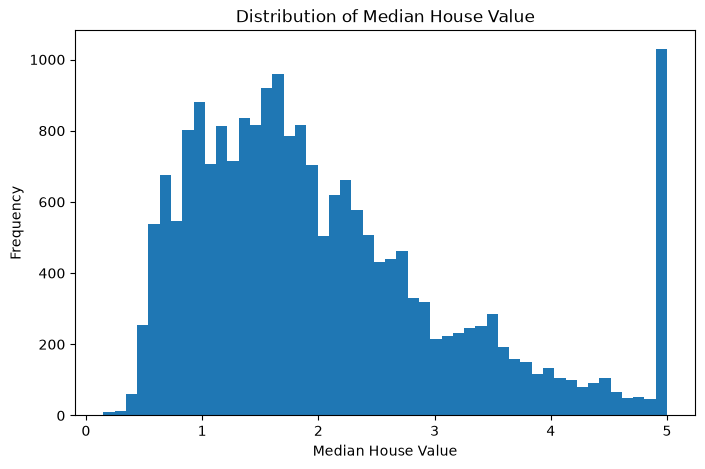

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=50)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

In [14]:
correlation = df.corr()

print(correlation["MedHouseValue"].sort_values(ascending=False))

MedHouseValue    1.000000
MedInc           0.688075
AveRooms         0.151948
HouseAge         0.105623
AveOccup        -0.023737
Population      -0.024650
Longitude       -0.045967
AveBedrms       -0.046701
Latitude        -0.144160
Name: MedHouseValue, dtype: float64


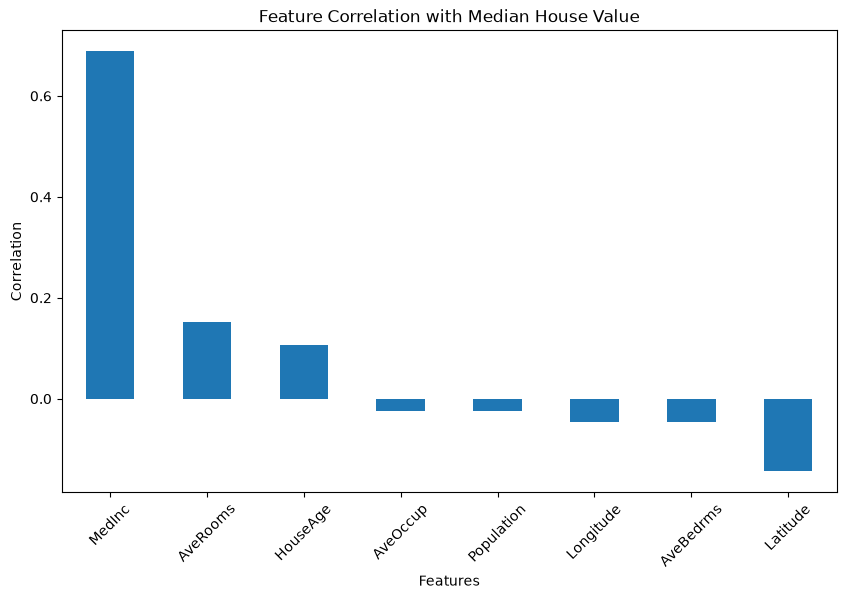

In [15]:

correlation_with_target = (
    df.corr()["MedHouseValue"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

correlation_with_target.drop("MedHouseValue").plot(
    kind="bar"
)

plt.title("Feature Correlation with Median House Value")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


In [19]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

print(dt_model)

DecisionTreeRegressor(random_state=42)


In [20]:
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [21]:
y_pred = dt_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0.414   1.203   5.00001 2.17    2.257   1.664   2.217   1.74    2.772
 5.00001]


In [22]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0.47700,0.41400
1,0.45800,1.20300
2,5.00001,5.00001
3,2.18600,2.17000
4,2.78000,2.25700
5,1.58700,1.66400
6,1.98200,2.21700
7,1.57500,1.74000
8,3.40000,2.77200
9,4.46600,5.00001


In [23]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.4541711942829458


In [24]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.494255717630063


In [25]:

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.7030332265476953


In [26]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.622823312540521


In [27]:

print("===================================")
print("Decision Tree Regression Results")
print("===================================")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Decision Tree Regression Results
MAE  : 0.4542
MSE  : 0.4943
RMSE : 0.7030
R²   : 0.6228


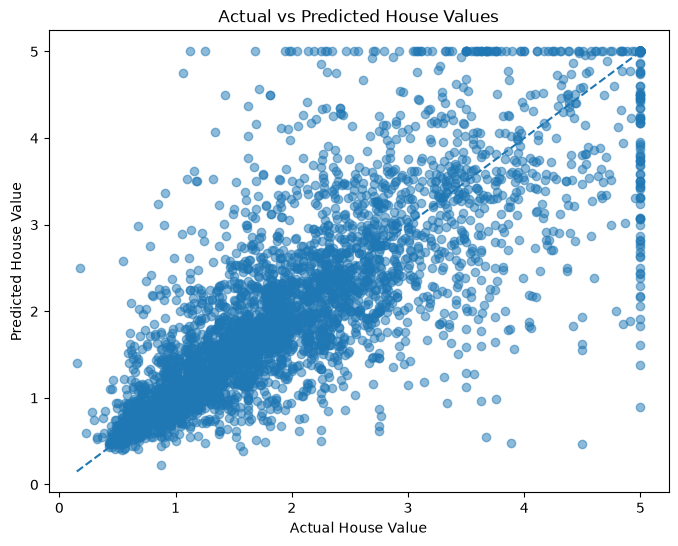

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.title("Actual vs Predicted House Values")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [29]:
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
20046    6.300000e-02
3024    -7.450000e-01
15663   -1.776357e-15
20484    1.600000e-02
9814     5.230000e-01
13311   -7.700000e-02
7113    -2.350000e-01
7668    -1.650000e-01
18246    6.280000e-01
5723    -5.340100e-01
Name: MedHouseValue, dtype: float64


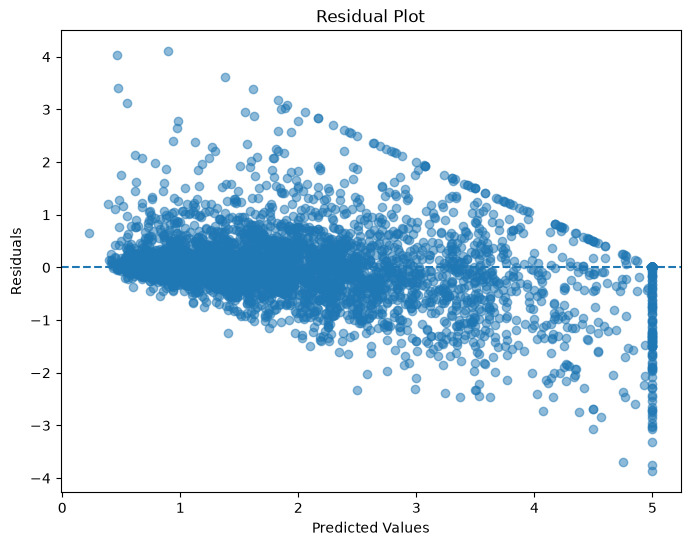

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [31]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 34
Number of Leaves: 15860


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,MedInc,0.528330
5,AveOccup,0.131160
6,Latitude,0.092413
7,Longitude,0.084109
2,AveRooms,0.052970
1,HouseAge,0.051690
4,Population,0.030547
3,AveBedrms,0.028782


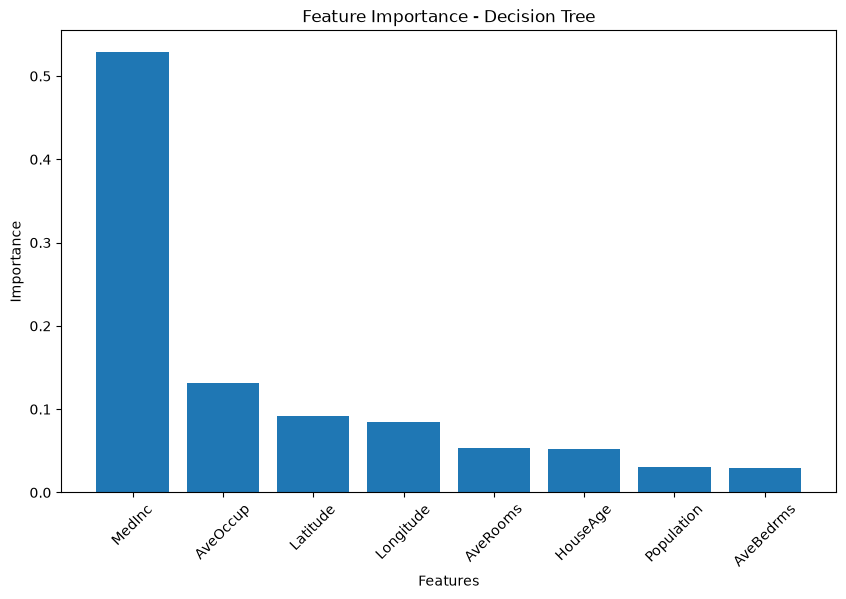

In [33]:
plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [34]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


In [35]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Grid Search completed!")

Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Grid Search completed!


In [36]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}


In [37]:

print("Best Cross-Validation R² Score:")
print(grid_search.best_score_)

Best Cross-Validation R² Score:
0.7189100556703816


In [38]:

best_model = grid_search.best_estimator_

print("Optimized Decision Tree:")
print(best_model)

Optimized Decision Tree:
DecisionTreeRegressor(max_depth=10, min_samples_leaf=8, random_state=42)


In [39]:
y_pred_best = best_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [40]:
mae_best = mean_absolute_error(
    y_test,
    y_pred_best
)

mse_best = mean_squared_error(
    y_test,
    y_pred_best
)

rmse_best = np.sqrt(mse_best)

r2_best = r2_score(
    y_test,
    y_pred_best
)

print("===================================")
print("Optimized Decision Tree Results")
print("===================================")

print(f"MAE  : {mae_best:.4f}")
print(f"MSE  : {mse_best:.4f}")
print(f"RMSE : {rmse_best:.4f}")
print(f"R²   : {r2_best:.4f}")

Optimized Decision Tree Results
MAE  : 0.4202
MSE  : 0.3793
RMSE : 0.6159
R²   : 0.7105


In [41]:

results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],
    "Before Tuning": [
        mae,
        mse,
        rmse,
        r2
    ],
    "After Tuning": [
        mae_best,
        mse_best,
        rmse_best,
        r2_best
    ]
})

results

,Metric,Before Tuning,After Tuning
0,MAE,0.454171,0.420190
1,MSE,0.494256,0.379322
2,RMSE,0.703033,0.615891
3,R2 Score,0.622823,0.710532


In [42]:
comparison_best = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best
})

comparison_best.head(10)

,Actual,Predicted
0,0.47700,0.532764
1,0.45800,0.726551
2,5.00001,4.968580
3,2.18600,2.322840
4,2.78000,2.048515
5,1.58700,1.600850
6,1.98200,2.171168
7,1.57500,1.698091
8,3.40000,2.342558
9,4.46600,5.000010


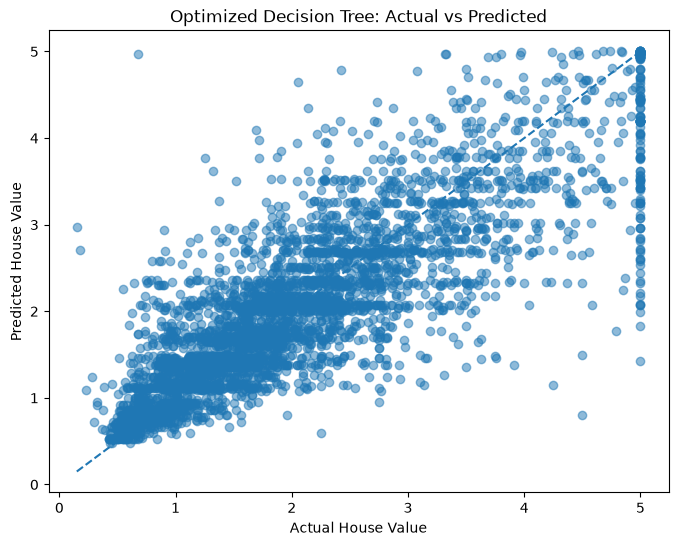

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.title("Optimized Decision Tree: Actual vs Predicted")

plt.show()

In [44]:

optimized_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

optimized_importance = optimized_importance.sort_values(
    by="Importance",
    ascending=False
)

optimized_importance

,Feature,Importance
0,MedInc,0.624330
5,AveOccup,0.132530
6,Latitude,0.078482
7,Longitude,0.064010
1,HouseAge,0.045852
2,AveRooms,0.035934
3,AveBedrms,0.010552
4,Population,0.008310


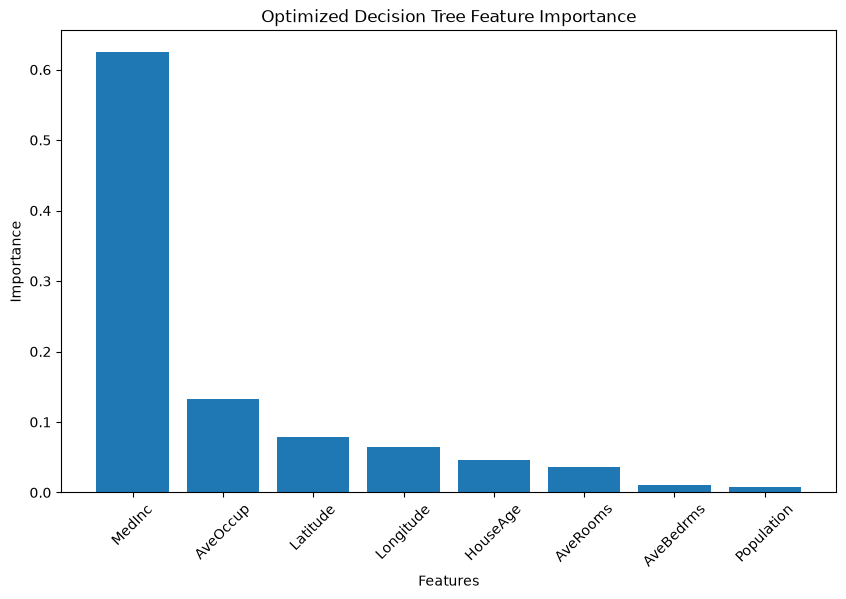

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    optimized_importance["Feature"],
    optimized_importance["Importance"]
)

plt.title("Optimized Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [46]:
# Take the first sample from test data
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)

print("Input:")
print(sample)

print("\nPredicted Median House Value:")
print(prediction[0])

print("\nActual Median House Value:")
print(y_test.iloc[0])

Input:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20046  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   

       Longitude  
20046    -119.01  

Predicted Median House Value:
0.5327637500000002

Actual Median House Value:
0.477


In [47]:
print("==============================================")
print("       DECISION TREE REGRESSION SUMMARY")
print("==============================================")

print("Dataset              : California Housing")
print("Algorithm            : Decision Tree Regressor")
print("Training Samples     :", len(X_train))
print("Testing Samples      :", len(X_test))

print("\nOriginal Model")
print("----------------------------------------------")
print(f"MAE                  : {mae:.4f}")
print(f"MSE                  : {mse:.4f}")
print(f"RMSE                 : {rmse:.4f}")
print(f"R² Score             : {r2:.4f}")

print("\nOptimized Model")
print("----------------------------------------------")
print(f"MAE                  : {mae_best:.4f}")
print(f"MSE                  : {mse_best:.4f}")
print(f"RMSE                 : {rmse_best:.4f}")
print(f"R² Score             : {r2_best:.4f}")

print("\nBest Parameters")
print("----------------------------------------------")
print(grid_search.best_params_)

       DECISION TREE REGRESSION SUMMARY
Dataset              : California Housing
Algorithm            : Decision Tree Regressor
Training Samples     : 16512
Testing Samples      : 4128

Original Model
----------------------------------------------
MAE                  : 0.4542
MSE                  : 0.4943
RMSE                 : 0.7030
R² Score             : 0.6228

Optimized Model
----------------------------------------------
MAE                  : 0.4202
MSE                  : 0.3793
RMSE                 : 0.6159
R² Score             : 0.7105

Best Parameters
----------------------------------------------
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2}
